# Exercise Sheet 7
### Name: Aryan Varshneya
### Matriculation Number: 261678

In [1]:
# Cell 1

import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

In [2]:
# Cell 2
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
# Cell 3
class CarlaDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column=None,
        transform=None
    ):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row["frame"]).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        if self.label_column:

            label = float(
                row[self.label_column]
            )

            return image, torch.tensor(label)

        return image

In [4]:
# Cell 4
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
# Cell 5
pedestrian_model = models.resnet18(
    weights=None
)

pedestrian_model.fc = nn.Linear(
    pedestrian_model.fc.in_features,
    1
)

pedestrian_model.load_state_dict(
    torch.load(
        "pedestrian_model.pth",
        map_location=device
    )
)

pedestrian_model = pedestrian_model.to(device)

pedestrian_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
# Cell 6
print(
    next(
        pedestrian_model.parameters()
    ).device
)

cuda:0


In [7]:
# Cell 7
id_labels = pd.read_csv(
    "dataset/test/test/labels.csv"
)

fog_labels = pd.read_csv(
    "dataset/test-fog/labels.csv"
)

night_labels = pd.read_csv(
    "dataset/test-night/labels.csv"
)

town_labels = pd.read_csv(
    "dataset/test-town-01/labels.csv"
)

In [8]:
# Cell 8
from PIL import Image
import matplotlib.pyplot as plt
import os

def show_examples(folder, title):
    images = sorted(os.listdir(folder))[:5]
    plt.figure(figsize=(15,3))
    for i, img_name in enumerate(images):
        img = Image.open(
            os.path.join(folder, img_name)
        )
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

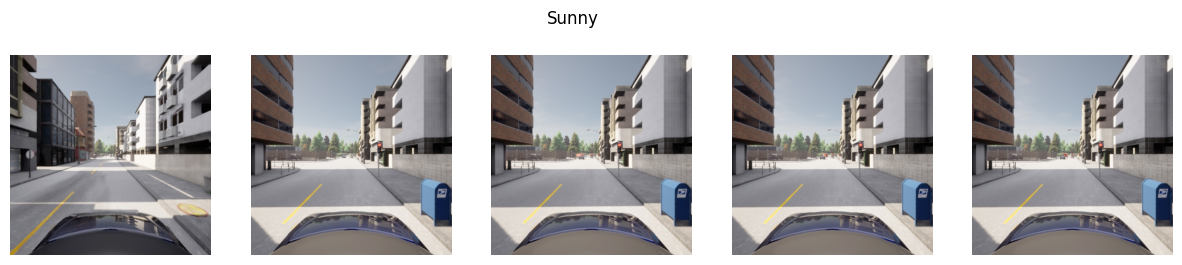

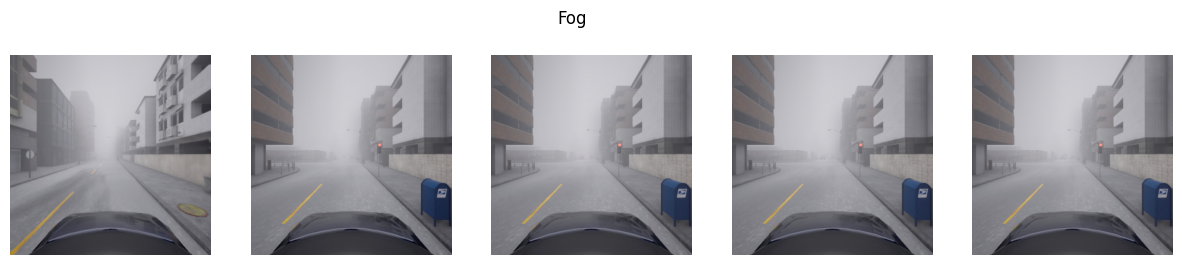

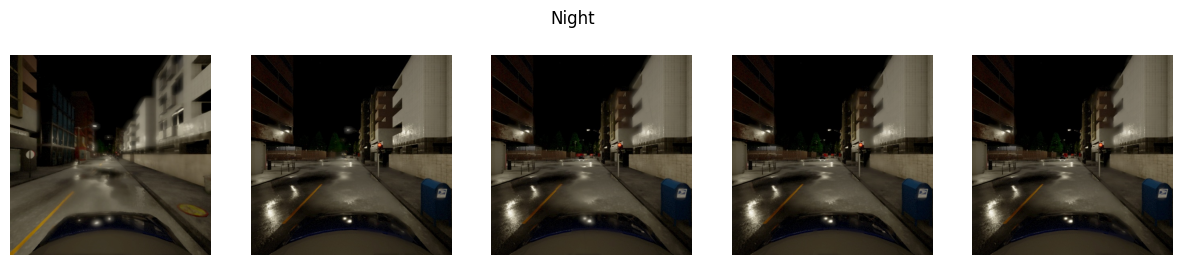

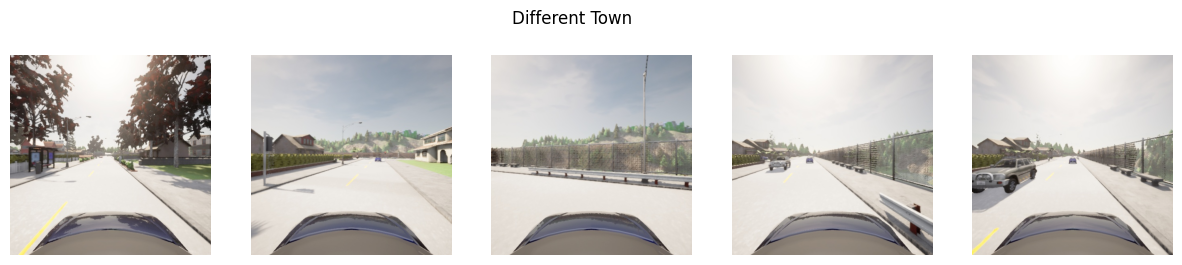

In [9]:
# Cell 9
show_examples(
    "dataset/test/rgb-front",
    "Sunny"
)

show_examples(
    "dataset/test-fog/rgb-front",
    "Fog"
)

show_examples(
    "dataset/test-night/rgb-front",
    "Night"
)

show_examples(
    "dataset/test-town-01/rgb-front",
    "Different Town"
)

In [10]:
# Cell 10
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

def show_shift_examples(folder, labels_file, title):

    labels = pd.read_csv(labels_file)

    frames = labels["frame"].head(5)

    plt.figure(figsize=(15,3))

    for i, frame in enumerate(frames):

        img_path = (
            f"{folder}/{str(frame).zfill(6)}.jpg"
        )

        img = Image.open(img_path)

        plt.subplot(1,5,i+1)

        plt.imshow(img)

        plt.axis("off")

    plt.suptitle(title)

    plt.show()

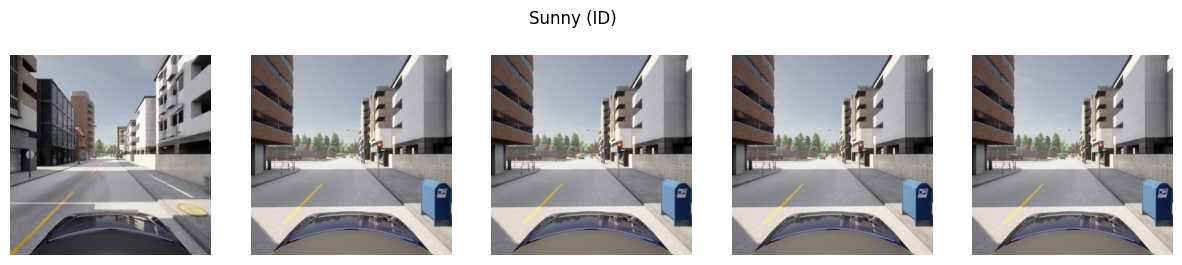

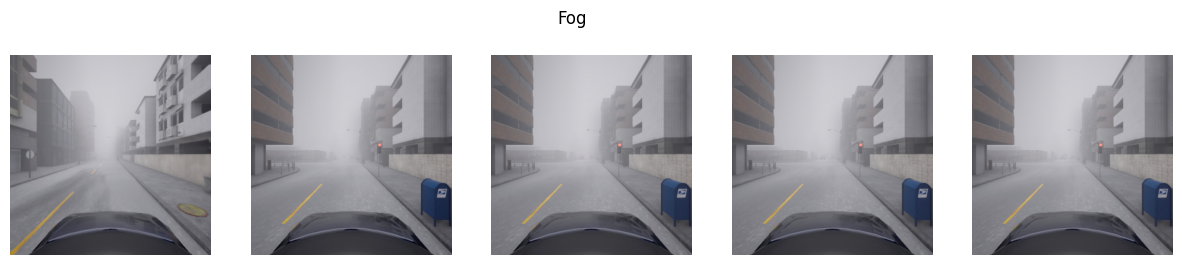

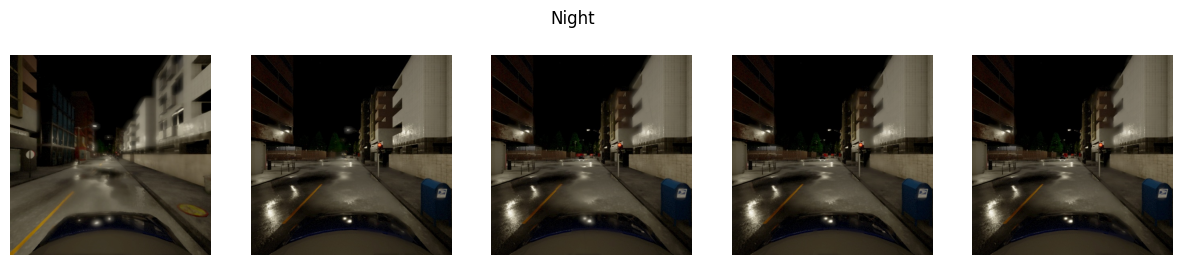

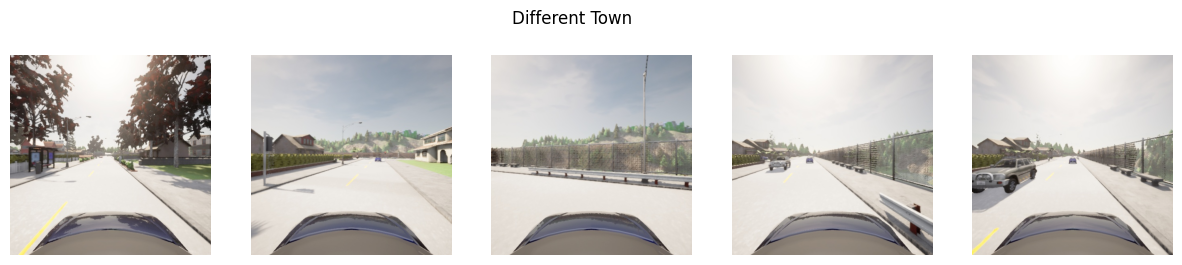

In [11]:
# Cell 11
show_shift_examples(
    "dataset/test/rgb-front",
    "dataset/test/labels.csv",
    "Sunny (ID)"
)

show_shift_examples(
    "dataset/test-fog/rgb-front",
    "dataset/test-fog/labels.csv",
    "Fog"
)

show_shift_examples(
    "dataset/test-night/rgb-front",
    "dataset/test-night/labels.csv",
    "Night"
)

show_shift_examples(
    "dataset/test-town-01/rgb-front",
    "dataset/test-town-01/labels.csv",
    "Different Town"
)

In [12]:
# Cell 12
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

pedestrian_model = models.resnet18(
    weights=None
)

pedestrian_model.fc = nn.Linear(
    pedestrian_model.fc.in_features,
    1
)

pedestrian_model.load_state_dict(
    torch.load(
        "pedestrian_model.pth",
        map_location=device
    )
)

pedestrian_model = pedestrian_model.to(device)

pedestrian_model.eval()

print(
    next(
        pedestrian_model.parameters()
    ).device
)

cuda:0


In [13]:
# Cell 13
test_dataset = CarlaDataset(
    csv_file="dataset/test/labels.csv",
    img_dir="dataset/test/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

fog_dataset = CarlaDataset(
    csv_file="dataset/test-fog/labels.csv",
    img_dir="dataset/test-fog/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

night_dataset = CarlaDataset(
    csv_file="dataset/test-night/labels.csv",
    img_dir="dataset/test-night/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

In [14]:
# Cell 14
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

fog_loader = DataLoader(
    fog_dataset,
    batch_size=32,
    shuffle=False
)

night_loader = DataLoader(
    night_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
# Cell 15
def mean_confidence(model, loader):

    model.eval()

    confidences = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            confidences.extend(
                probs.cpu().numpy().flatten()
            )

    return np.mean(confidences)

In [16]:
# Cell 16
id_conf = mean_confidence(
    pedestrian_model,
    test_loader
)

fog_conf = mean_confidence(
    pedestrian_model,
    fog_loader
)

night_conf = mean_confidence(
    pedestrian_model,
    night_loader
)

print("Test:", id_conf)
print("Fog:", fog_conf)
print("Night:", night_conf)

Test: 0.13725005
Fog: 0.03553398
Night: 0.044549324


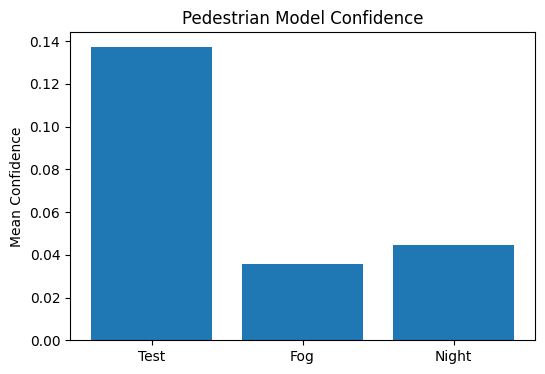

In [17]:
# Cell 17
datasets = [
    "Test",
    "Fog",
    "Night"
]

confidences = [
    id_conf,
    fog_conf,
    night_conf
]

plt.figure(figsize=(6,4))

plt.bar(
    datasets,
    confidences
)

plt.ylabel("Mean Confidence")

plt.title(
    "Pedestrian Model Confidence"
)

plt.show()

In [18]:
# Cell 18
traffic_light_model = models.resnet18(
    weights=None
)

traffic_light_model.fc = nn.Linear(
    traffic_light_model.fc.in_features,
    1
)

traffic_light_model.load_state_dict(
    torch.load(
        "traffic_light_model.pth",
        map_location=device
    )
)

traffic_light_model = traffic_light_model.to(device)

traffic_light_model.eval()

print(
    next(
        traffic_light_model.parameters()
    ).device
)

cuda:0


In [19]:
# Cell 19
test_tl_dataset = CarlaDataset(
    csv_file="dataset/test/labels.csv",
    img_dir="dataset/test/rgb-front",
    label_column="has_traffic_light",
    transform=transform
)

fog_tl_dataset = CarlaDataset(
    csv_file="dataset/test-fog/labels.csv",
    img_dir="dataset/test-fog/rgb-front",
    label_column="has_traffic_light",
    transform=transform
)

night_tl_dataset = CarlaDataset(
    csv_file="dataset/test-night/labels.csv",
    img_dir="dataset/test-night/rgb-front",
    label_column="has_traffic_light",
    transform=transform
)

In [20]:
# Cell 20
test_tl_loader = DataLoader(
    test_tl_dataset,
    batch_size=32,
    shuffle=False
)

fog_tl_loader = DataLoader(
    fog_tl_dataset,
    batch_size=32,
    shuffle=False
)

night_tl_loader = DataLoader(
    night_tl_dataset,
    batch_size=32,
    shuffle=False
)

In [21]:
# Cell 21
test_tl_conf = mean_confidence(
    traffic_light_model,
    test_tl_loader
)

fog_tl_conf = mean_confidence(
    traffic_light_model,
    fog_tl_loader
)

night_tl_conf = mean_confidence(
    traffic_light_model,
    night_tl_loader
)

print("Traffic Light Model")

print("Test:", test_tl_conf)

print("Fog:", fog_tl_conf)

print("Night:", night_tl_conf)

Traffic Light Model
Test: 0.7490501
Fog: 0.36470175
Night: 0.21772979


In [22]:
# Cell 22
vehicle_model = models.resnet18(
    weights=None
)

vehicle_model.fc = nn.Linear(
    vehicle_model.fc.in_features,
    1
)

vehicle_model.load_state_dict(
    torch.load(
        "vehicle_model.pth",
        map_location=device
    )
)

vehicle_model = vehicle_model.to(device)

vehicle_model.eval()

print(
    next(
        vehicle_model.parameters()
    ).device
)

cuda:0


In [23]:
# Cell 23
test_vehicle_dataset = CarlaDataset(
    csv_file="dataset/test/labels.csv",
    img_dir="dataset/test/rgb-front",
    label_column="has_vehicle",
    transform=transform
)

fog_vehicle_dataset = CarlaDataset(
    csv_file="dataset/test-fog/labels.csv",
    img_dir="dataset/test-fog/rgb-front",
    label_column="has_vehicle",
    transform=transform
)

night_vehicle_dataset = CarlaDataset(
    csv_file="dataset/test-night/labels.csv",
    img_dir="dataset/test-night/rgb-front",
    label_column="has_vehicle",
    transform=transform
)

In [24]:
# Cell 24
test_vehicle_loader = DataLoader(
    test_vehicle_dataset,
    batch_size=32,
    shuffle=False
)

fog_vehicle_loader = DataLoader(
    fog_vehicle_dataset,
    batch_size=32,
    shuffle=False
)

night_vehicle_loader = DataLoader(
    night_vehicle_dataset,
    batch_size=32,
    shuffle=False
)

In [25]:
# Cell 25
test_vehicle_conf = mean_confidence(
    vehicle_model,
    test_vehicle_loader
)

fog_vehicle_conf = mean_confidence(
    vehicle_model,
    fog_vehicle_loader
)

night_vehicle_conf = mean_confidence(
    vehicle_model,
    night_vehicle_loader
)

print("Vehicle Model")

print("Test:", test_vehicle_conf)

print("Fog:", fog_vehicle_conf)

print("Night:", night_vehicle_conf)

Vehicle Model
Test: 0.70383835
Fog: 0.40795606
Night: 0.4088561


In [26]:
# Cell 26
results = pd.DataFrame({

    "Model": [
        "Pedestrian",
        "Traffic Light",
        "Vehicle"
    ],

    "Test": [
        id_conf,
        test_tl_conf,
        test_vehicle_conf
    ],

    "Fog": [
        fog_conf,
        fog_tl_conf,
        fog_vehicle_conf
    ],

    "Night": [
        night_conf,
        night_tl_conf,
        night_vehicle_conf
    ]
})

results

,Model,Test,Fog,Night
0,Pedestrian,0.137250,0.035534,0.044549
1,Traffic Light,0.749050,0.364702,0.217730
2,Vehicle,0.703838,0.407956,0.408856


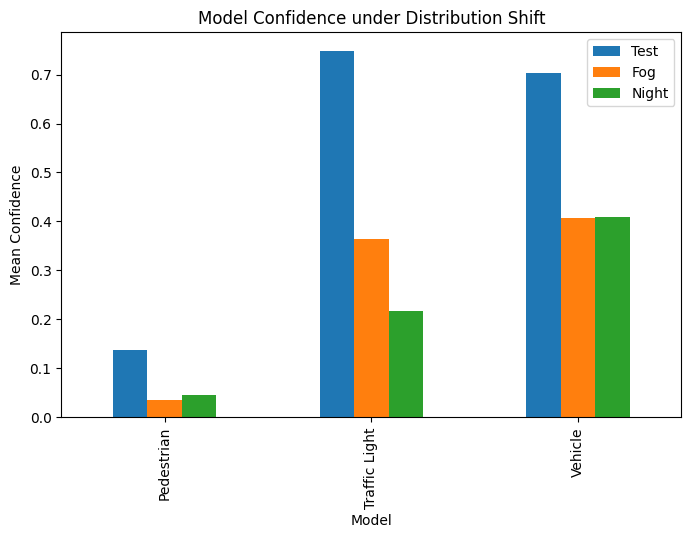

In [27]:
# Cell 27
results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Mean Confidence")

plt.title(
    "Model Confidence under Distribution Shift"
)

plt.show()

In [30]:
# Cell 28
def get_msp_scores(model, loader):
    model.eval()

    scores = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            scores.extend(
                probs.cpu().numpy().flatten()
            )

    return np.array(scores)

In [31]:
# Cell 29
id_scores = get_msp_scores(
    traffic_light_model,
    test_tl_loader
)

fog_scores = get_msp_scores(
    traffic_light_model,
    fog_tl_loader
)

night_scores = get_msp_scores(
    traffic_light_model,
    night_tl_loader
)

print("ID samples:", len(id_scores))
print("Fog samples:", len(fog_scores))
print("Night samples:", len(night_scores))

ID samples: 3600
Fog samples: 3600
Night samples: 3600


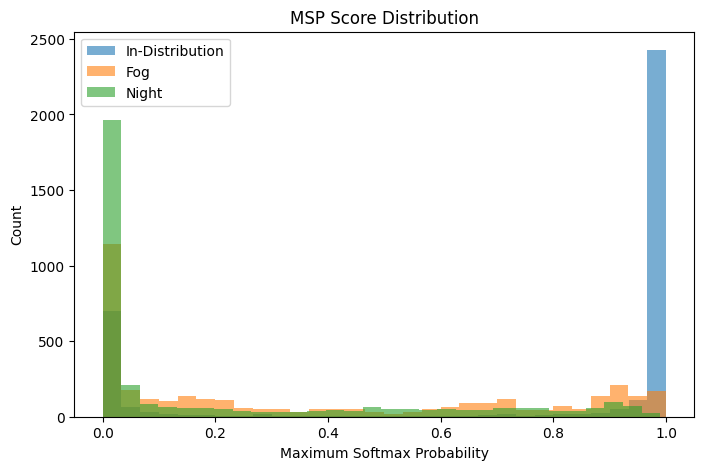

In [32]:
# Cell 30
plt.figure(figsize=(8,5))

plt.hist(
    id_scores,
    bins=30,
    alpha=0.6,
    label="In-Distribution"
)

plt.hist(
    fog_scores,
    bins=30,
    alpha=0.6,
    label="Fog"
)

plt.hist(
    night_scores,
    bins=30,
    alpha=0.6,
    label="Night"
)

plt.xlabel("Maximum Softmax Probability")

plt.ylabel("Count")

plt.title(
    "MSP Score Distribution"
)

plt.legend()

plt.show()

In [33]:
# Cell 31
ood_scores = np.concatenate(
    [fog_scores, night_scores]
)

all_scores = np.concatenate(
    [id_scores, ood_scores]
)

labels = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(ood_scores))
])

In [34]:
# Cell 32
auroc = roc_auc_score(
    labels,
    -all_scores
)

print(
    f"AUROC: {auroc:.4f}"
)

AUROC: 0.7968


In [35]:
# Cell 33
def extract_features(model, loader):

    model.eval()

    features = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            x = model.conv1(images)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)

            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)

            x = model.avgpool(x)

            x = torch.flatten(x, 1)

            features.append(
                x.cpu().numpy()
            )

    return np.vstack(features)

In [36]:
# Cell 34
val_tl_dataset = CarlaDataset(
    csv_file="dataset/validation/labels.csv",
    img_dir="dataset/validation/rgb-front",
    label_column="has_traffic_light",
    transform=transform
)

val_tl_loader = DataLoader(
    val_tl_dataset,
    batch_size=32,
    shuffle=False
)

In [37]:
# Cell 35
train_features = extract_features(
    traffic_light_model,
    val_tl_loader
)

id_features = extract_features(
    traffic_light_model,
    test_tl_loader
)

fog_features = extract_features(
    traffic_light_model,
    fog_tl_loader
)

night_features = extract_features(
    traffic_light_model,
    night_tl_loader
)

print(train_features.shape)

(3600, 512)


In [39]:
# Cell 36
knn = NearestNeighbors(
    n_neighbors=1
)

knn.fit(
    train_features
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [40]:
# Cell 37
id_dist, _ = knn.kneighbors(
    id_features
)

fog_dist, _ = knn.kneighbors(
    fog_features
)

night_dist, _ = knn.kneighbors(
    night_features
)

id_dist = id_dist.flatten()
fog_dist = fog_dist.flatten()
night_dist = night_dist.flatten()

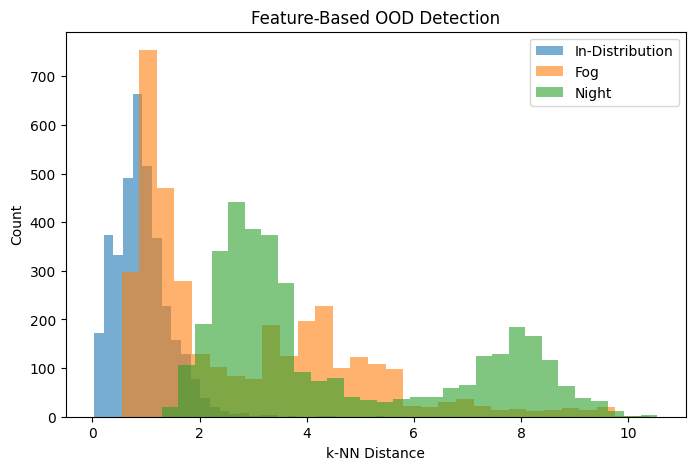

In [41]:
# Cell 38
plt.figure(figsize=(8,5))

plt.hist(
    id_dist,
    bins=30,
    alpha=0.6,
    label="In-Distribution"
)

plt.hist(
    fog_dist,
    bins=30,
    alpha=0.6,
    label="Fog"
)

plt.hist(
    night_dist,
    bins=30,
    alpha=0.6,
    label="Night"
)

plt.xlabel("k-NN Distance")

plt.ylabel("Count")

plt.title(
    "Feature-Based OOD Detection"
)

plt.legend()

plt.show()

In [42]:
# Cell 39
ood_dist = np.concatenate([
    fog_dist,
    night_dist
])

all_dist = np.concatenate([
    id_dist,
    ood_dist
])

labels = np.concatenate([
    np.zeros(len(id_dist)),
    np.ones(len(ood_dist))
])

knn_auroc = roc_auc_score(
    labels,
    all_dist
)

print(
    f"k-NN AUROC: {knn_auroc:.4f}"
)

k-NN AUROC: 0.9205


In [43]:
# Cell 40
msp_auroc = 0.7968
comparison = pd.DataFrame({
    "Method": [
        "MSP",
        "k-NN"
    ],
    "AUROC": [
        0.7968,
        knn_auroc
    ]
})

comparison

,Method,AUROC
0,MSP,0.796800
1,k-NN,0.920511
